Nurkamil kyzy Zhumakan
Week3 -Project: Churn Predic4on for StreamWorks Media.

Loading, reading , and exploring data

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
stream_works = pd.read_csv(r"C:\Users\kanza\Downloads\streamworks\streamworks_user_data.csv")
stream_works.head()



,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


In [7]:
stream_works.describe()

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


In [8]:
stream_works.value_counts()

user_id  age   gender  signup_date  last_active_date  country  subscription_type  average_watch_hours  mobile_app_usage_pct  complaints_raised  received_promotions  referred_by_friend  is_churned  monthly_fee
2500.0   35.0  Other   26-01-23     13-07-25          Canada   Basic              77.7                 77.6                  2.0                No                   Yes                 0.0         5.99           1
1001.0   56.0  Other   02-04-25     13-07-25          France   Standard           42.6                 77.4                  1.0                No                   No                  1.0         10.99          1
1002.0   69.0  Male    02-01-23     13-07-25          India    Basic              65.3                 98.0                  4.0                No                   Yes                 1.0         5.99           1
1003.0   46.0  Male    21-08-22     13-07-25          UK       Premium            40.1                 47.8                  0.0                No   

In [9]:
# Check for missing values
stream_works.isnull().sum()

user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

Cleaning and preparing data

In [10]:
# Convert date columns to datetime format
stream_works['signup_date'] = pd.to_datetime(
    stream_works['signup_date'],
    errors='coerce'
)

stream_works['last_active_date'] = pd.to_datetime(
    stream_works['last_active_date'],
    errors='coerce'
)


C:\Users\kanza\AppData\Local\Temp\ipykernel_6196\3132791116.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stream_works['signup_date'] = pd.to_datetime(


In [11]:
# Check the data types of the date columns
stream_works[['signup_date', 'last_active_date']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   signup_date       1498 non-null   datetime64[ns]
 1   last_active_date  1498 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 23.6 KB


In [12]:
#Create a new column for tenure in days
stream_works['tenure_days'] = (stream_works['last_active_date'] - stream_works['signup_date']).dt.days
stream_works

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,tenure_days
0,1001.0,56.0,Other,2025-02-04,2025-07-13,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99,159.0
1,1002.0,69.0,Male,2023-02-01,2025-07-13,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99,893.0
2,1003.0,46.0,Male,2022-08-21,2025-07-13,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99,1057.0
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99,668.0
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99,715.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99,595.0
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,USA,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN,-142.0
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,UK,Premium,12.6,49.7,0.0,No,No,1.0,13.99,922.0
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,USA,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99,993.0


In [13]:
# Create a new column to indicate if a user is loyal (tenure > 180 days)
stream_works['is_loyal'] = np.where(stream_works['tenure_days'] > 180, 1, 0)
stream_works

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,tenure_days,is_loyal
0,1001.0,56.0,Other,2025-02-04,2025-07-13,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99,159.0,0
1,1002.0,69.0,Male,2023-02-01,2025-07-13,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99,893.0,1
2,1003.0,46.0,Male,2022-08-21,2025-07-13,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99,1057.0,1
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99,668.0,1
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99,715.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99,595.0,1
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,USA,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN,-142.0,0
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,UK,Premium,12.6,49.7,0.0,No,No,1.0,13.99,922.0,1
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,USA,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99,993.0,1


In [14]:
# Encode the subscription_type column using LabelEncoder
# LabelEncoder converts categorical labels into numeric form, 
# which is necessary for many machine learning algorithms that 
# require numerical input. By encoding the subscription_type column,
# we can prepare the data for further analysis or modeling.
#LabelEncoder is a simple and efficient way to convert categorical variables into a format that can be easily 
# used by machine learning algorithms. It assigns a unique integer to each category in the subscription_type column, 
# allowing us to work with the data in a numerical format while preserving the categorical information.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
stream_works['subscription_type'] = le.fit_transform(stream_works['subscription_type'])
stream_works

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,tenure_days,is_loyal
0,1001.0,56.0,Other,2025-02-04,2025-07-13,France,2,42.6,77.4,1.0,No,No,1.0,10.99,159.0,0
1,1002.0,69.0,Male,2023-02-01,2025-07-13,India,0,65.3,98.0,4.0,No,Yes,1.0,5.99,893.0,1
2,1003.0,46.0,Male,2022-08-21,2025-07-13,UK,1,40.1,47.8,0.0,No,Yes,1.0,13.99,1057.0,1
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,1,5.8,53.2,1.0,Yes,Yes,1.0,13.99,668.0,1
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,2,32.7,16.8,5.0,No,Yes,0.0,9.99,715.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,2,7.5,88.7,0.0,No,No,0.0,9.99,595.0,1
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,USA,0,48.7,42.0,NaN,Yes,Yes,1.0,NaN,-142.0,0
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,UK,1,12.6,49.7,0.0,No,No,1.0,13.99,922.0,1
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,USA,0,3.0,91.7,2.0,No,Yes,0.0,5.99,993.0,1


In [15]:
# Encode the device_type column using one-hot encoding
# One-hot encoding is a technique used to convert categorical variables into a format 
# that can be provided to machine learning algorithms. It creates new binary columns for each 
# category in the device_type column,
stream_works = pd.get_dummies(stream_works,drop_first=True,dtype=int)
stream_works.head(5)

,user_id,age,signup_date,last_active_date,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee,...,is_loyal,gender_Male,gender_Other,country_France,country_Germany,country_India,country_UK,country_USA,received_promotions_Yes,referred_by_friend_Yes
0,1001.0,56.0,2025-02-04,2025-07-13,2,42.6,77.4,1.0,1.0,10.99,...,0,0,1,1,0,0,0,0,0,0
1,1002.0,69.0,2023-02-01,2025-07-13,0,65.3,98.0,4.0,1.0,5.99,...,1,1,0,0,0,1,0,0,0,1
2,1003.0,46.0,2022-08-21,2025-07-13,1,40.1,47.8,0.0,1.0,13.99,...,1,1,0,0,0,0,1,0,0,1
3,1004.0,32.0,2023-09-14,2025-07-13,1,5.8,53.2,1.0,1.0,13.99,...,1,0,1,0,1,0,0,0,1,1
4,1005.0,60.0,2023-07-29,2025-07-13,2,32.7,16.8,5.0,0.0,9.99,...,1,0,0,0,0,1,0,0,0,1


Feature Engineering

In [16]:
#Creating new features 
#watch fre ratio
stream_works['watch_freq_ratio'] = stream_works['average_watch_hours'] / (stream_works['tenure_days'] + 1)
stream_works.head(5)

,user_id,age,signup_date,last_active_date,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee,...,gender_Male,gender_Other,country_France,country_Germany,country_India,country_UK,country_USA,received_promotions_Yes,referred_by_friend_Yes,watch_freq_ratio
0,1001.0,56.0,2025-02-04,2025-07-13,2,42.6,77.4,1.0,1.0,10.99,...,0,1,1,0,0,0,0,0,0,0.266250
1,1002.0,69.0,2023-02-01,2025-07-13,0,65.3,98.0,4.0,1.0,5.99,...,1,0,0,0,1,0,0,0,1,0.073043
2,1003.0,46.0,2022-08-21,2025-07-13,1,40.1,47.8,0.0,1.0,13.99,...,1,0,0,0,0,1,0,0,1,0.037902
3,1004.0,32.0,2023-09-14,2025-07-13,1,5.8,53.2,1.0,1.0,13.99,...,0,1,0,1,0,0,0,1,1,0.008670
4,1005.0,60.0,2023-07-29,2025-07-13,2,32.7,16.8,5.0,0.0,9.99,...,0,0,0,0,1,0,0,0,1,0.045670


In [17]:
#heavy mobile user
stream_works['heavy_mobile_user'] = np.where(stream_works['mobile_app_usage_pct'] > 10, 1, 0)
stream_works.head(5)

,user_id,age,signup_date,last_active_date,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee,...,gender_Other,country_France,country_Germany,country_India,country_UK,country_USA,received_promotions_Yes,referred_by_friend_Yes,watch_freq_ratio,heavy_mobile_user
0,1001.0,56.0,2025-02-04,2025-07-13,2,42.6,77.4,1.0,1.0,10.99,...,1,1,0,0,0,0,0,0,0.266250,1
1,1002.0,69.0,2023-02-01,2025-07-13,0,65.3,98.0,4.0,1.0,5.99,...,0,0,0,1,0,0,0,1,0.073043,1
2,1003.0,46.0,2022-08-21,2025-07-13,1,40.1,47.8,0.0,1.0,13.99,...,0,0,0,0,1,0,0,1,0.037902,1
3,1004.0,32.0,2023-09-14,2025-07-13,1,5.8,53.2,1.0,1.0,13.99,...,1,0,1,0,0,0,1,1,0.008670,1
4,1005.0,60.0,2023-07-29,2025-07-13,2,32.7,16.8,5.0,0.0,9.99,...,0,0,0,1,0,0,0,1,0.045670,1



Statistic analysis


In [18]:
#Use Chi-square test to check if churn is related to gender,
#received_promotions, or referred_by_friend
import numpy as np
from scipy.stats import chi2_contingency


def chi_square_test(stream_works, target, categorical_cols):
    results = {}
    for col in categorical_cols:
        table = pd.crosstab(stream_works[target], stream_works[col])
        chi2, p, dof, expected = chi2_contingency(table)
        results[col] = {
            'chi2_stat': chi2,
            'p_value': p,
            'dof': dof,
            'table': table,
            'expected': expected
        }
    return results

In [19]:
churned = stream_works[stream_works['is_churned'] == 1]['average_watch_hours']
retained = stream_works[stream_works['is_churned'] == 0]['average_watch_hours']

In [20]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(churned, retained, equal_var=False)  # Welch's t-test

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("=> Significant difference in watch_time between churned and retained users")
else:
    print("=> No significant difference in watch_time between the groups")


t-statistic: nan
p-value: nan
=> No significant difference in watch_time between the groups


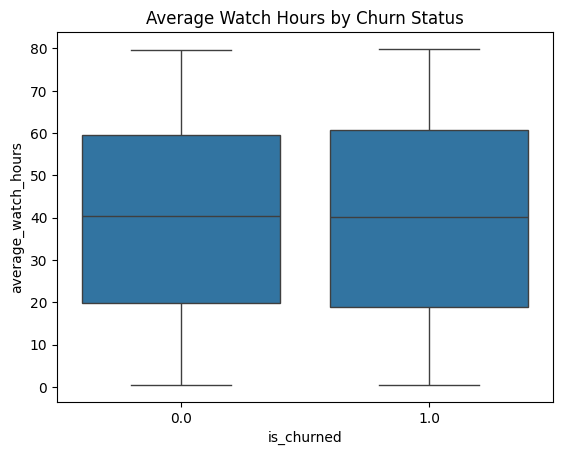

In [21]:
#Correlation Analysis
#Use charts (boxplots, bar plots, histograms) to visualise key differences
from psutil import users
import matplotlib.pyplot as plt
sns.boxplot(x='is_churned', y='average_watch_hours', data=stream_works)
plt.title('Average Watch Hours by Churn Status')
plt.show()  

Predictive Modelling

In [22]:
# Check how many NaNs are in y
print(stream_works['is_churned'].isna().sum())


1


In [23]:
stream_works.dropna(inplace=True)

In [24]:
# Check how many NaNs are in y
print(stream_works['is_churned'].isna().sum())


0


In [25]:
stream_works.drop(['signup_date', 'last_active_date'], axis=1, inplace=True)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(stream_works), columns=stream_works.columns)
y = stream_works['is_churned']
X = df_scaled.drop(['is_churned','user_id'], axis=1)




In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [28]:
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
model = LogisticRegression(class_weight= 'balanced') #instantce
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [29]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns)
coefficients = coefficients.sort_values(ascending=False)

print(coefficients)

is_loyal                   0.154116
country_UK                 0.150640
country_India              0.073350
subscription_type          0.071390
mobile_app_usage_pct       0.024027
country_USA               -0.007334
country_Germany           -0.008366
watch_freq_ratio          -0.009182
referred_by_friend_Yes    -0.010363
country_France            -0.011170
age                       -0.020196
complaints_raised         -0.029030
heavy_mobile_user         -0.041889
average_watch_hours       -0.092347
monthly_fee               -0.100590
gender_Other              -0.108605
tenure_days               -0.115445
gender_Male               -0.130421
received_promotions_Yes   -0.151470
dtype: float64


In [30]:
y_pred = model.predict(X_test)

In [31]:
print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))(y_test, y_pred)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))


[[117  89]
 [ 32  30]]
Precision: 0.25210084033613445
Recall: 0.4838709677419355
Accuracy: 0.5485074626865671


In [32]:
from sklearn.linear_model  import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df_scaled = pd.DataFrame(scaler.fit_transform(stream_works.drop(['average_watch_hours'], axis=1)), columns=stream_works.drop(['average_watch_hours'], axis=1).columns)
model = LinearRegression() #instantce
X = df_scaled
y = stream_works['average_watch_hours']
X_test,X_train, y_test,y_train = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred=model.predict(X_test)

In [34]:
print('r2:', r2_score(y_test, y_pred))
print('mse:', mean_squared_error(y_test, y_pred))

r2: -0.10305199763026462
mse: 575.4509890331105


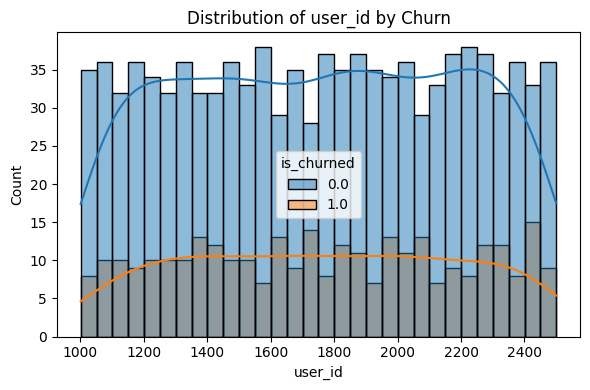

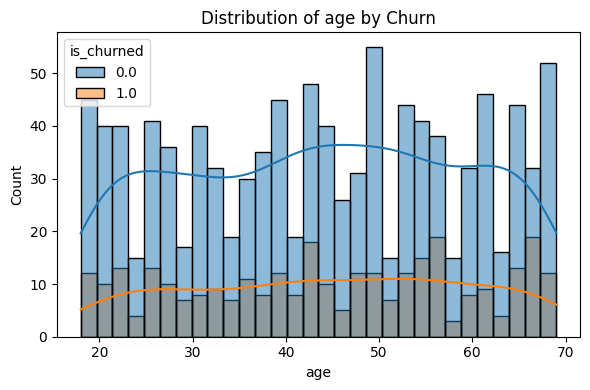

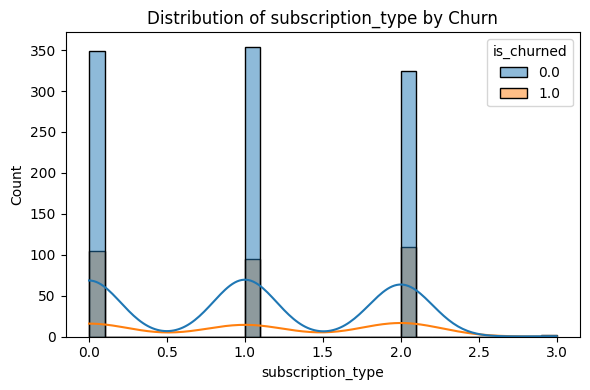

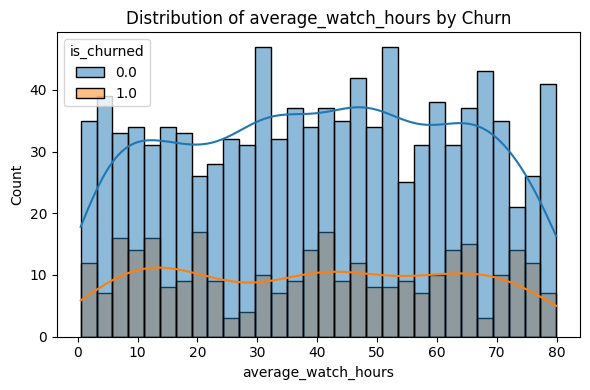

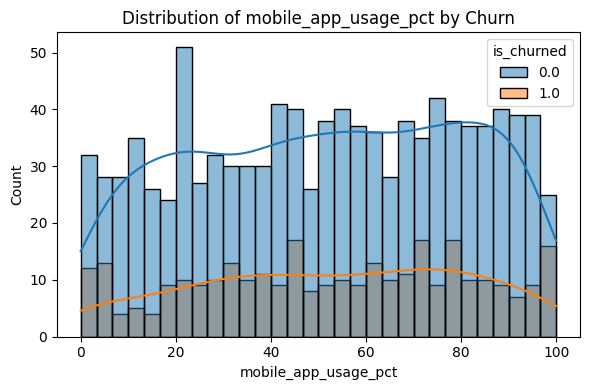

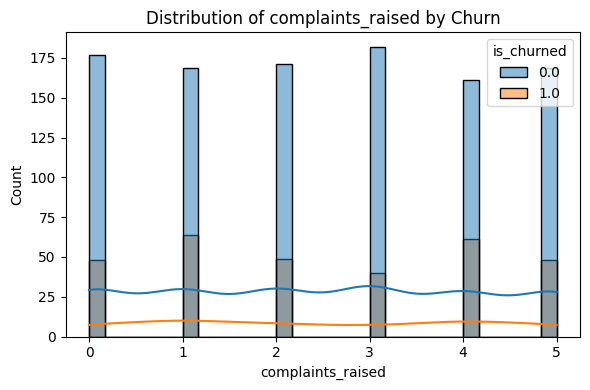

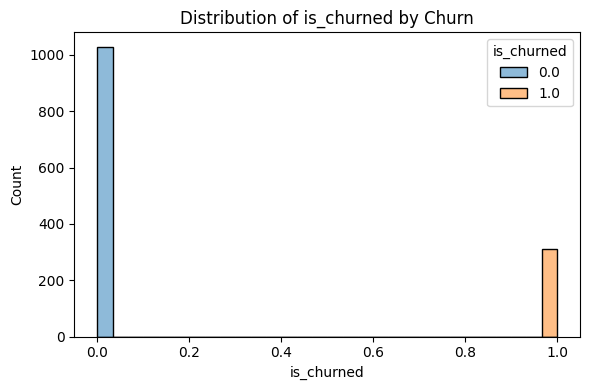

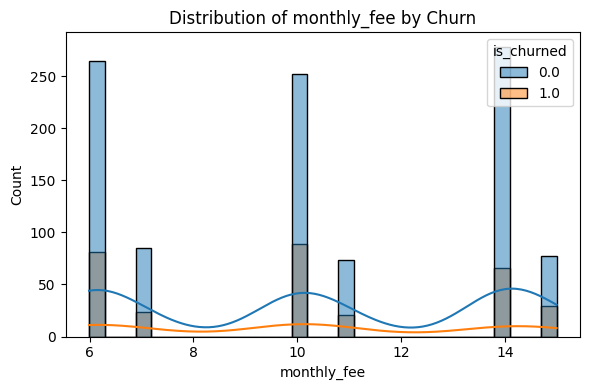

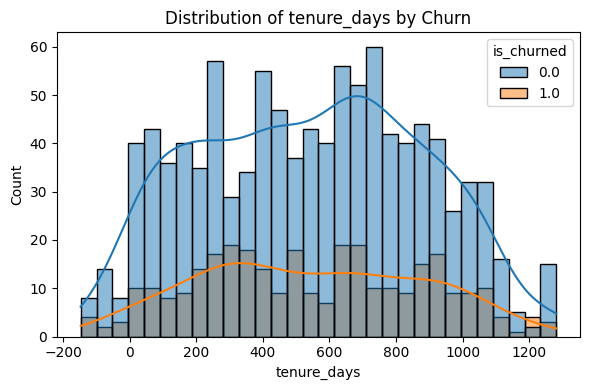

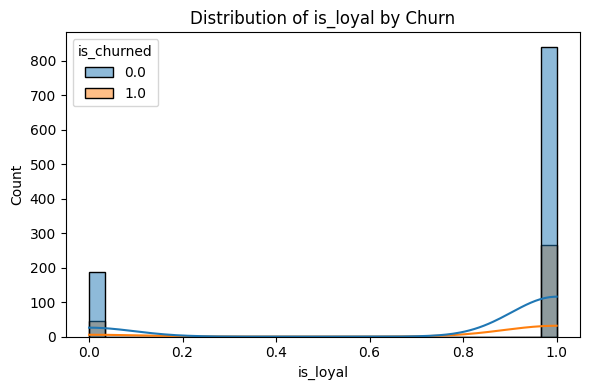

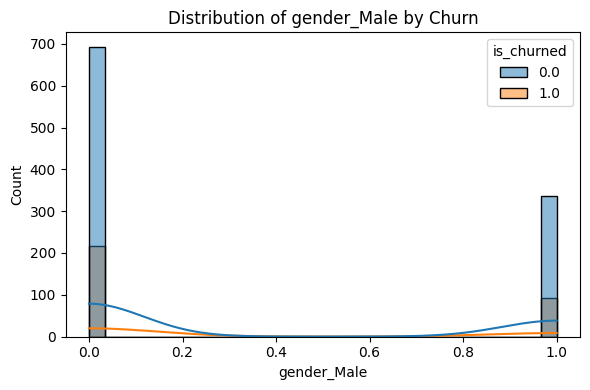

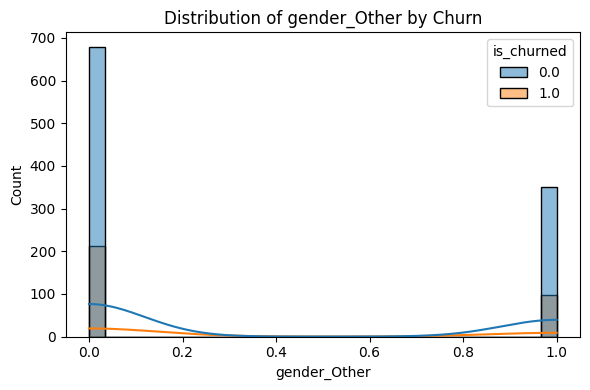

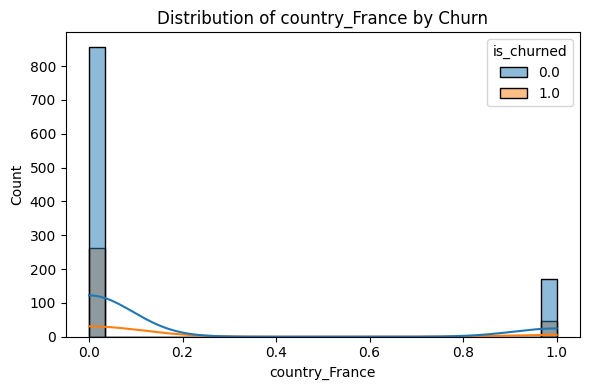

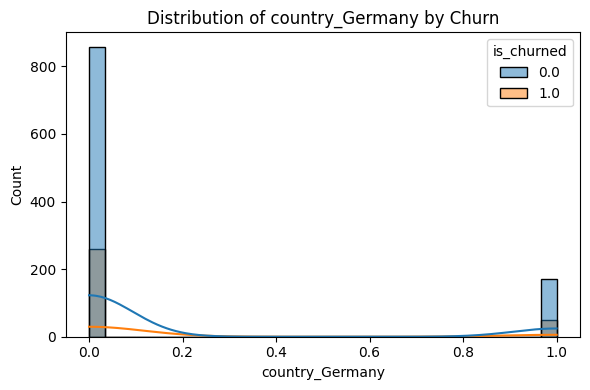

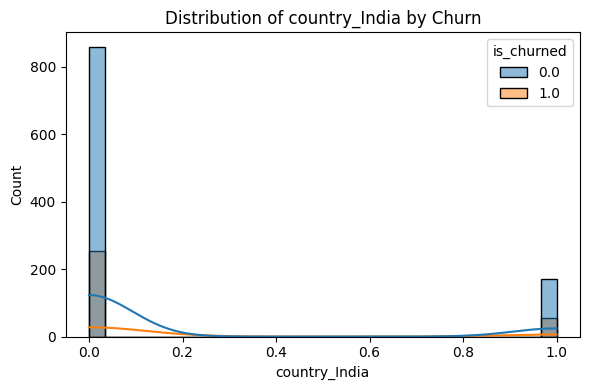

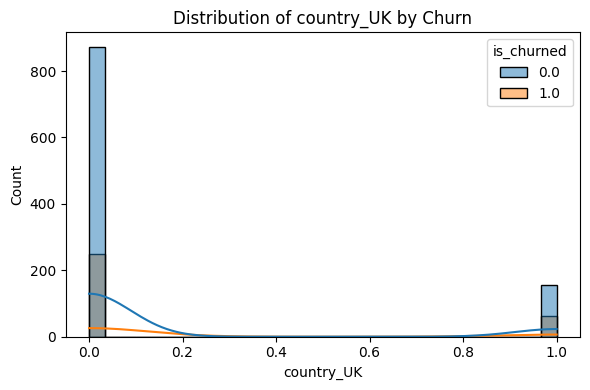

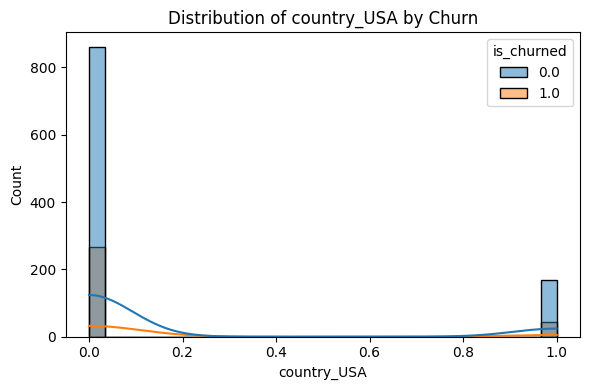

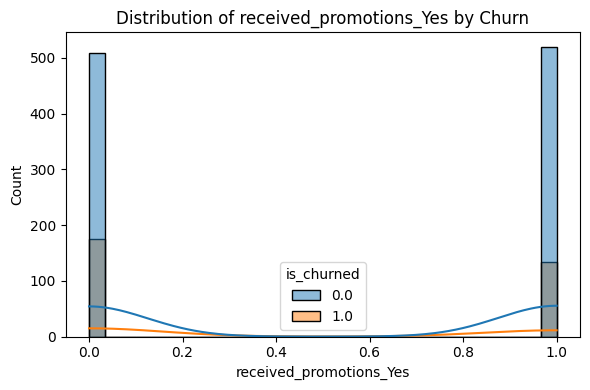

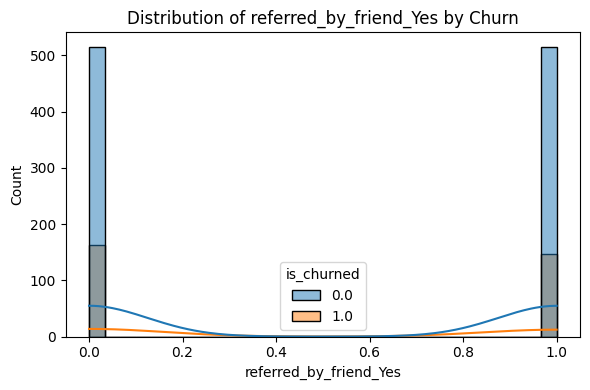

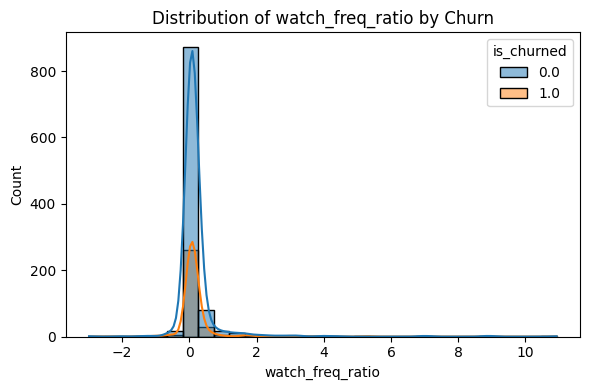

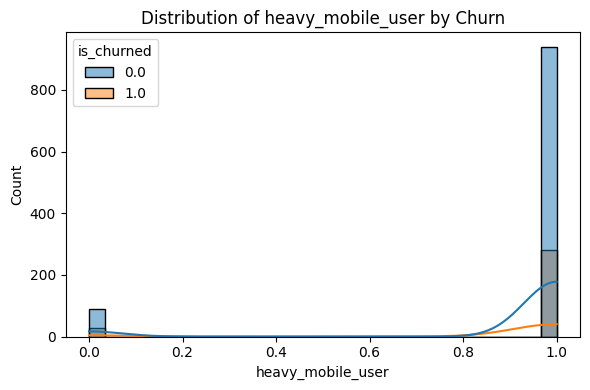

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = stream_works.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=stream_works,
        x=col,
        hue='is_churned',
        kde=True,
        bins=30
    )
    plt.title(f'Distribution of {col} by Churn')
    plt.tight_layout()
    plt.show()

In [ ]:
stream_works.to_csv('cleaned_streamworks_user_data.csv', index=False)  